In [1]:
#del F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
import matplotlib.pyplot as plt
import torch.optim.swa_utils as swa_utils

import operator
from functools import reduce
from functools import partial
from timeit import default_timer
from utilities3 import *
import pickle
import torch.optim as optim
import os
from tqdm import tqdm

from Adam import Adam

from torch.optim import Adam as adam
torch.manual_seed(2)
np.random.seed(2)

if torch.cuda.is_available():
    print("CUDA is available. GPU will be used.")
    device = torch.device('cuda:0')
else:
    print("CUDA is not available. CPU will be used.")
    device = torch.device('cpu')

CUDA is available. GPU will be used.


In [2]:
torch.cuda.is_available()

True

In [3]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ===================== Sinusoidal Positional Encodings =====================
def sinusoidal_pe(L, D, device):
    pos = torch.arange(L, device=device).float().unsqueeze(1)  # [L,1]
    div = torch.exp(torch.arange(0, D, 2, device=device).float() * (-np.log(10000.0) / D))
    pe = torch.zeros(L, D, device=device)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe  # [L,D]

def sinusoidal_pe_2d(nx, nt, D, device):
    # separable: PE(x,t) = PE_x(x) + PE_t(t)
    pe_x = sinusoidal_pe(nx, D, device).unsqueeze(1)  # [Nx,1,D]
    pe_t = sinusoidal_pe(nt, D, device).unsqueeze(0)  # [1,Nt,D]
    return pe_x + pe_t                                # [Nx,Nt,D]

# ===================== ViT Blocks =====================
class _MHSA(nn.Module):
    def __init__(self, d_model, n_heads, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dh = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.scale = self.dh ** -0.5
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(d_model, d_model)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x):
        B, S, D = x.shape
        qkv = self.qkv(x).reshape(B, S, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]            # [B,h,S,dh] each
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        y = attn @ v                                 # [B,h,S,dh]
        y = y.transpose(1, 2).reshape(B, S, D)
        y = self.proj_drop(self.proj(y))
        return y

class _MLP(nn.Module):
    def __init__(self, d_model, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(d_model * mlp_ratio)
        self.fc1 = nn.Linear(d_model, hidden)
        self.fc2 = nn.Linear(hidden, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class _ViTBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4.0, attn_dropout=0.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = _MHSA(d_model, n_heads, attn_dropout, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp   = _MLP(d_model, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# ===================== 2D 패치 ViT (Context 전용) =====================
class ContextOnlyViT2D(nn.Module):
    """
    context 이미지를 2D 패치로 잘라 ViT 인코딩.
    입력:
      context: [B, N_x, N_t, C_ctx(±coords)]
    출력:
      h_pool:  [B, d_model]  # [CLS] 요약, 하이퍼넷 입력
    하이퍼파라미터:
      patch_x, patch_t: 패치 커널 크기
      stride_x, stride_t: 패치 스트라이드(기본=패치크기, 비중첩)
      add_coords: True면 (x,t) 정규화 좌표 2채널을 context에 concat
    """
    def __init__(
        self,
        c_ctx,
        d_model=256,
        n_heads=4,
        depth=4,
        patch_x=16,
        patch_t=4,
        stride_x=None,
        stride_t=None,
        mlp_ratio=4.0,
        dropout=0.0,
        attn_dropout=0.0,
        use_cls_token=True,
        add_coords=False,
    ):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.depth   = depth
        self.px = patch_x
        self.pt = patch_t
        self.sx = stride_x if stride_x is not None else patch_x
        self.st = stride_t if stride_t is not None else patch_t
        self.use_cls = use_cls_token
        self.add_coords = add_coords

        in_ch = c_ctx + (2 if add_coords else 0)  # (x,t) 좌표 추가 여부
        self.patch_embed = nn.Linear(in_ch * self.px * self.pt, d_model)

        if self.use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.blocks = nn.ModuleList([
            _ViTBlock(d_model, n_heads, mlp_ratio=mlp_ratio, attn_dropout=attn_dropout, dropout=dropout)
        for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)

    @staticmethod
    def _compute_endpad(L, k, s):
        if L < k:
            return k - L
        # 최소 pad로 (L - k) % s == 0 맞추기 (우측/하단에만 padding)
        r = (L - k) % s
        return 0 if r == 0 else (s - r)

    def _maybe_add_coords(self, ctx):
        # ctx: [B,Nx,Nt,C] -> concat [x_norm, t_norm]
        if not self.add_coords:
            return ctx
        B, Nx, Nt, _ = ctx.shape
        device = ctx.device
        x = torch.linspace(0, 1, steps=Nx, device=device).view(1, Nx, 1, 1).expand(B, Nx, Nt, 1)
        t = torch.linspace(0, 1, steps=Nt, device=device).view(1, 1, Nt, 1).expand(B, Nx, Nt, 1)
        return torch.cat([ctx, x, t], dim=-1)

    def forward(self, context):
        """
        context: [B, N_x, N_t, C_ctx]
        return : [B, d_model]
        """
        B, Nx, Nt, Cc = context.shape
        device = context.device

        x = self._maybe_add_coords(context)                    # [B,Nx,Nt,Cc(+2)]
        x = x.permute(0, 3, 1, 2).contiguous()                 # [B,C,H=Nx,W=Nt]

        # 필요한 만큼만 우측/하단 패딩
        pad_h = self._compute_endpad(Nx, self.px, self.sx)
        pad_w = self._compute_endpad(Nt, self.pt, self.st)
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))  # (left,right,top,bottom)

        H, W = x.shape[-2], x.shape[-1]
        nph = (H - self.px) // self.sx + 1      # #patch along x
        npw = (W - self.pt) // self.st + 1      # #patch along t

        # Unfold로 2D 패치 추출: [B, C*px*pt, nph*npw]
        unfold = F.unfold(
            x,
            kernel_size=(self.px, self.pt),
            stride=(self.sx, self.st),
            padding=(0, 0)
        )
        # [B, L, C*px*pt]
        patches = unfold.transpose(1, 2)
        # Linear embed -> [B, L, d]
        tok = self.patch_embed(patches)

        # 2D 패치 좌표 기준 위치임베딩
        pe2d = sinusoidal_pe_2d(nph, npw, self.d_model, device)    # [nph,npw,d]
        pe2d = pe2d.view(1, nph * npw, self.d_model)               # [1,L,d]
        tok = tok + pe2d                                           # [B,L,d]

        # [CLS] + Encoder
        if self.use_cls:
            cls = self.cls_token.expand(B, -1, -1)                 # [B,1,d]
            xseq = torch.cat([cls, tok], dim=1)                    # [B,1+L,d]
        else:
            xseq = tok

        for blk in self.blocks:
            xseq = blk(xseq)
        xseq = self.norm(xseq)

        h_pool = xseq[:, 0, :] if self.use_cls else xseq.mean(dim=1)
        tok_out = xseq[:, 1:, :] if self.use_cls else xseq               # [B, L, d]
        grid = tok_out.view(B, nph, npw, self.d_model)                   # [B, nph, npw, d]
        H_x_patch = grid.mean(dim=2)                                     # [B, nph, d]
        return h_pool, H_x_patch, nph

# ===================== 외부 가중치만 쓰는 1D 스펙트럴 컨볼루션 =====================
class SpectralConv1dExternal(nn.Module):
    """
    내부 파라미터 없이, 전달된 '복소' 가중치로만 스펙트럴 곱 수행.
    expected weights: [B, in_ch, out_ch, modes]
    """
    def __init__(self, in_channels, out_channels, modes_high):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = modes_high

    def _mul(self, inp_modes, w):
        # inp_modes: [B, in_ch, M] or [B, T, in_ch, M]
        # w       : [B, in_ch, out_ch, M]
        if inp_modes.dim() == 3:
            return torch.einsum("bim,biom->bom", inp_modes, w)   # -> [B,out_ch,M]
        elif inp_modes.dim() == 4:
            return torch.einsum("btim,biom->btom", inp_modes, w) # -> [B,T,out_ch,M]
        else:
            raise ValueError(f"Unexpected shape {inp_modes.shape}")

    def forward(self, x, weights):
        if weights.dtype != torch.cfloat and weights.dtype != torch.cdouble:
            raise ValueError("weights must be complex (torch.cfloat or cdouble)")
        B = x.size(0)
        Nt = x.size(1) if x.dim() == 4 else None
        x_ft = torch.fft.rfft(x)  # last dim -> modes

        if x.dim() == 3:
            out_ft = torch.zeros(B, self.out_channels, x.size(-1)//2 + 1, device=x.device, dtype=x_ft.dtype)
            out_ft[:, :, :self.modes_high] = self._mul(x_ft[:, :, :self.modes_high], weights)
        else:  # dim==4
            out_ft = torch.zeros(B, Nt, self.out_channels, x.size(-1)//2 + 1, device=x.device, dtype=x_ft.dtype)
            out_ft[:, :, :, :self.modes_high] = self._mul(x_ft[:, :, :, :self.modes_high], weights)

        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

# ===================== Context 2D-ViT HyperNet + Pure FNO (Window) =====================
class ContextFNOHyperViT2D(nn.Module):
    """
    - Context 이미지를 2D 패치 ViT로 요약 (맥락만 ViT)
    - [CLS] 임베딩 → 하이퍼넷 → 각 FNO 블록의 '복소 Fourier 가중치' 직접 생성
    - Window는 FNO(스펙트럴 + Conv1d)만 사용 (Conv1d는 게이팅 없이 고정)
    입력:
      context: [B, N_x, N_t, C_ctx]
      window : [B, N_x, C_win]
    출력:
      out: [B, N_x, 1]
    """
    def __init__(
        self,
        mode1d,
        width,
        depth,
        C_win,
        C_ctx,
        n_heads=8,
        d_model=None,
        dropout=0.0,
        vit_depth=4,
        patch_x=64,
        patch_t=4,
        stride_x=None,
        stride_t=None,
        mlp_ratio=4.0,
        attn_dropout=0.0,
        add_ctx_coords=True,         # (x,t) 두 좌표 채널을 context에 추가
        weight_init_scale=0.2,
    ):
        super().__init__()
        self.depth   = depth
        self.mode1d  = mode1d
        self.width   = width
        self.d_model = d_model or width

        # 윈도우에 x-그리드(+1) 붙여 채널 리프트 → [B,W,Nx]
        self.fc00 = nn.Linear(C_win + 1, width, bias=False)

        # 2D 패치 ViT (맥락 전용)
        self.ctx_vit = ContextOnlyViT2D(
            c_ctx=C_ctx,                       # 좌표는 내부에서 add_ctx_coords로 추가
            d_model=self.d_model,
            n_heads=n_heads,
            depth=vit_depth,
            patch_x=patch_x,
            patch_t=patch_t,
            stride_x=stride_x,
            stride_t=stride_t,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            attn_dropout=attn_dropout,
            use_cls_token=True,
            add_coords=add_ctx_coords,
        )

        # 스펙트럴 분기: 외부 복소 가중치
        self.fouriers = nn.ModuleList([SpectralConv1dExternal(width, width, mode1d) for _ in range(depth)])
        self.convs    = nn.ModuleList([nn.Conv1d(width, width, 1, padding=0) for _ in range(depth)])

        # 하이퍼넷: h_pool → (실수/허수) → complex weights [B,W,W,M]
        self.weight_scale = nn.Parameter(torch.tensor(weight_init_scale))
        self.heads_real = nn.ModuleList([nn.Linear(self.d_model, mode1d * width * width) for _ in range(depth)])
        self.heads_imag = nn.ModuleList([nn.Linear(self.d_model, mode1d * width * width) for _ in range(depth)])

        # 출력 헤드
        self.fc10 = nn.Linear(width, 128, bias=False)
        self.fc20 = nn.Linear(128, 1)
         # FiLM 헤드: x별 gamma/beta
        self.film_gamma = nn.Linear(self.d_model, self.width)
        self.film_beta  = nn.Linear(self.d_model, self.width)

    @staticmethod
    def make_xgrid(B, N_x, device):
        return torch.linspace(0, 1, steps=N_x, device=device).view(1, N_x, 1).repeat(B, 1, 1)

    def _context_aug(self, context, add_coords):
        # context: [B,Nx,Nt,C]
        if not add_coords:
            return context
        B, Nx, Nt, _ = context.shape
        dev = context.device
        x = torch.linspace(0, 1, steps=Nx, device=dev).view(1, Nx, 1, 1).expand(B, Nx, Nt, 1)
        t = torch.linspace(0, 1, steps=Nt, device=dev).view(1, 1, Nt, 1).expand(B, Nx, Nt, 1)
        return torch.cat([context, x, t], dim=-1)

    def _hyper_weights(self, h_pool):
        B = h_pool.size(0)
        W_list = []
        for i in range(self.depth):
            wr = self.heads_real[i](h_pool).view(B, self.width, self.width, self.mode1d)
            wi = self.heads_imag[i](h_pool).view(B, self.width, self.width, self.mode1d)
            Wc = torch.complex(wr, wi) * self.weight_scale
            W_list.append(Wc)
        return W_list

    def forward(self, context, window):
        """
        context: [B,Nx,Nt,C_ctx]
        window : [B,Nx,C_win]
        """
        B, Nx = window.size(0), window.size(1)
        dev = window.device

        # 1) 컨텍스트 → 전역/로컬 요약
        h_pool, Hx_patch, nph = self.ctx_vit(context)   # Hx_patch: [B, nph, d]

        # 2) x 해상도 맞추기 (nearest 업샘플)
        #    [B, nph, d] -> [B, d, nph] -> interpolate -> [B, d, Nx] -> [B, Nx, d]
        Hx = F.interpolate(Hx_patch.permute(0,2,1), size=Nx, mode="nearest")\
              .permute(0,2,1).contiguous()  # [B, Nx, d]

        # 3) 하이퍼 Fourier 가중치(전역)
        W_list = self._hyper_weights(h_pool)

        # 2) 윈도우 경로: 순수 FNO
        gx = self.make_xgrid(B, Nx, dev)            # [B,Nx,1]
        window_aug = torch.cat([window, gx], dim=-1)
        x0 = self.fc00(window_aug).permute(0, 2, 1).contiguous()  # [B,W,Nx]

        for i in range(self.depth):
            x1 = self.fouriers[i](x0, weights=W_list[i])  # 복소 가중치 사용
            x2 = self.convs[i](x0)
            # --- FiLM (로컬 컨텍스트) ---
            gamma = self.film_gamma(Hx).permute(0,2,1)        # [B,W,Nx]
            beta  = self.film_beta(Hx).permute(0,2,1)         # [B,W,Nx]
            x_loc = gamma * (x1+x2) + beta                  # x-가변
           # x_loc = x1
            x0 = F.gelu(x_loc) + x0                           # 잔차

        x0 = x0.permute(0, 2, 1).contiguous()  # [B,Nx,W]
        x0 = F.gelu(self.fc10(x0))
        out = self.fc20(x0)                    # [B,Nx,1]
        return out
    
    def train_forward(self, context, window_seq):
        """
        context   : [B, N_x, N_t, C_ctx]
        window_seq: [B, N_x, N_w, C_win]
        return    : [B, N_x, N_w, 1]
        """
        B, N_x, N_t, _ = context.shape
        N_w = window_seq.size(2)
        device = window_seq.device
    
        # 1) 컨텍스트 → 전역/로컬 요약 (2D 패치 ViT)
        #    ctx_vit는 (h_pool, Hx_patch, nph)를 반환하도록 앞서 수정되어 있어야 합니다.
        h_pool, Hx_patch, nph = self.ctx_vit(context)              # h_pool: [B,d], Hx_patch: [B,nph,d]
    
        # x 해상도로 업샘플: [B, nph, d] -> [B, N_x, d]
        Hx = F.interpolate(Hx_patch.permute(0, 2, 1), size=N_x, mode="nearest") \
                .permute(0, 2, 1).contiguous()                     # [B, N_x, d_model]
    
        # FiLM 파라미터 (x-별): [B, N_x, d] -> [B, W, N_x]
        gamma = self.film_gamma(Hx).permute(0, 2, 1).contiguous()  # [B, W, N_x]
        beta  = self.film_beta(Hx).permute(0, 2, 1).contiguous()   # [B, W, N_x]
    
        # 2) 하이퍼넷으로 Fourier 복소 가중치 (샘플당 1회)
        W_list = self._hyper_weights(h_pool)                       # list of [B, W, W, M] (complex), len=depth
    
        # 3) 윈도우 리프트: [B, N_x, N_w, Cw] -> [B*N_w, W, N_x]
        gx = self.make_xgrid(B, N_x, device)                       # [B, N_x, 1]
        window_aug = torch.cat([window_seq, gx.unsqueeze(2).expand(-1, -1, N_w, -1)], dim=-1)
        x0 = self.fc00(window_aug).permute(0, 2, 3, 1).contiguous()  # [B, N_w, W, N_x]
        x0 = x0.view(B * N_w, self.width, N_x)                       # [B*N_w, W, N_x]
    
        # FiLM 파라미터도 창 차원으로 브로드캐스트
        gamma_flat = gamma.unsqueeze(1).expand(-1, N_w, -1, -1).contiguous().view(B * N_w, self.width, N_x)
        beta_flat  = beta .unsqueeze(1).expand(-1, N_w, -1, -1).contiguous().view(B * N_w, self.width, N_x)
    
        # 4) FNO 스택
        for i in range(self.depth):
            # 하이퍼 가중치 창 차원으로 반복
            Wi = W_list[i].unsqueeze(1).expand(-1, N_w, -1, -1, -1).contiguous() \
                            .view(B * N_w, self.width, self.width, self.mode1d)  # [B*N_w, W, W, M]
    
            x1 = self.fouriers[i](x0, weights=Wi)                 # 스펙트럴 (전역 컨텍스트)
            x2 = self.convs[i](x0)                                # 포인트와이즈
    
            # x-별 로컬 FiLM 변조
            x_loc = gamma_flat * (x1+x2) + beta_flat
            #x_loc = x1
            x0 = F.gelu(x_loc) + x0                               # 잔차
    
        # 5) 출력 헤드
        x0 = x0.view(B, N_w, self.width, N_x).permute(0, 3, 1, 2).contiguous()  # [B, N_x, N_w, W]
        x0 = F.gelu(self.fc10(x0))                                              # [B, N_x, N_w, 128]
        out = self.fc20(x0)                                                     # [B, N_x, N_w, 1]
        return out

Vanila $\psi$- FNO

In [4]:
import pickle

with open(file='trainingdataset_no_source_01_500_100_05.pickle', mode='rb') as f:
    dataset=pickle.load(f)[:,:]


with open(file='testdataset_no_source_01_5_100_05.pickle', mode='rb') as f:
    testset=pickle.load(f)[:,:]


XX = dataset[:,:,:20,0].unsqueeze(-1).to(device)
consiI = dataset[:,:,:20,1].unsqueeze(-1).to(device)

In [5]:
learning_rate = 0.0005
step_size = 100
re = 3
gamma = 0.5
#C_ctx = x.size(-1)
#C_win = xl.size(-1)
#print('C_ctx =', C_ctx, 'C_win =', C_win)   # 확인용

# 올바른 생성자 인자 순서: (mode1d, width, depth, C_win, C_ctx)
model = ContextFNOHyperViT2D(16,96,4,4,1).to(device)
#print(count_params(model))
BSIZE = 20
#print(count_params(model))
lambd = 5

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re*1e-3)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 200, 1e-5)
myloss = LpLoss(size_average=True)
myloss2 = LpLoss(size_average=True)
for ep in range(5000):

    for j in range(25):
        x = XX[BSIZE*j:BSIZE*(j+1)]
        consi = consiI[BSIZE*j:BSIZE*(j+1)]
        model.train()
        t1 = default_timer()
        train_mse = 0
        train_l2 = 0
        train_l2_2 = 0
        
    
        optimizer.zero_grad()
    
        xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
        xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)
    
        f0 = model.train_forward(100*(torch.roll(x, -1, dims = 2)-x)[:,:,0:19],xl)
        f1 = model.train_forward(100*(torch.roll(x, -1, dims = 2)-x)[:,:,0:19],xr)
                
        l2_tm = lambd*myloss(((0.128))*(f0-f1)[:,:,0:19,0], (torch.roll(x, -1, dims = 2)-x)[:,:,0:19,0].detach())
    
        MM = model.train_forward(100*(torch.roll(x, -1, dims = 2)-x)[:,:,0:19], torch.cat((x,x,x,x), dim = 3))
        
        train_l2_tm = l2_tm.item()
        l2_F = myloss(MM, consi) #Burgers
        #l2_F_roll = myloss(torch.roll(F,128,dims=1), torch.roll(FF,128,dims=1).detach()) #Burgers
        #l2 += myloss(F, x[0].cuda()) #advection
        l2 = l2_tm + l2_F 
        l2.backward() # use the l2 relative loss
        train_l2_consi = l2_F.item()
        optimizer.step()
    
        #print(l2_tm, l2_F)
                

        

    scheduler.step()
    model.eval()

    print(ep, train_l2_tm/lambd, train_l2_consi)

    t2 = default_timer()

    

0 0.9164046287536621 0.8081592917442322
1 0.757765245437622 0.7306466102600098
2 0.6862814426422119 0.6992037296295166
3 0.5541734218597412 0.6562782526016235
4 0.4671792030334473 0.4917464852333069
5 0.41705713272094724 0.4748375117778778
6 0.39850854873657227 0.41916704177856445
7 0.3904977083206177 0.46972545981407166
8 0.35570266246795657 0.4045988619327545
9 0.3226358890533447 0.3826800286769867
10 0.3438637018203735 0.4024476110935211
11 0.30736937522888186 0.3426407277584076
12 0.2731955051422119 0.34984833002090454
13 0.3254392623901367 0.3640228807926178
14 0.2954370975494385 0.3409605920314789
15 0.2577017307281494 0.34924814105033875
16 0.2638798713684082 0.31478121876716614
17 0.28453335762023924 0.28395500779151917
18 0.24740266799926758 0.33088555932044983
19 0.22820167541503905 0.29703566431999207
20 0.2218224048614502 0.2859925329685211
21 0.23174676895141602 0.2462318241596222
22 0.23982274532318115 0.28795433044433594
23 0.23955788612365722 0.31347763538360596
24 0.24

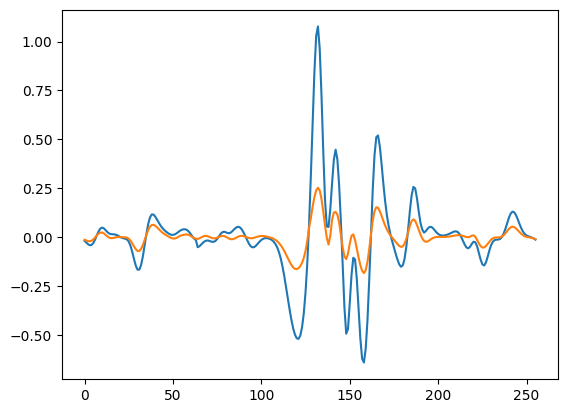

In [9]:
#model = ContextFNOAttn2D(16,64,5,4,1).to(device)
model.eval()
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[:1,:,:19,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xl)-model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xr)).squeeze().detach().cpu())
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[2:3,:,:19,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xl)-model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xr)).squeeze().detach().cpu())

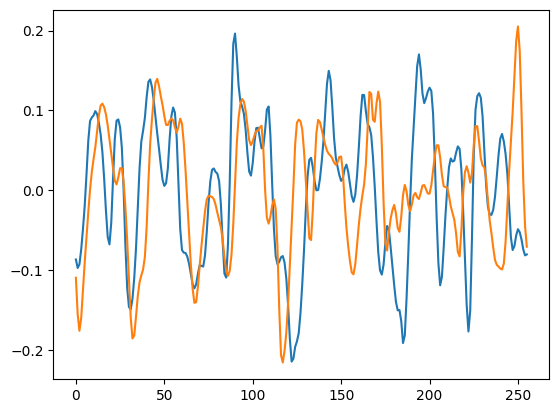

In [101]:
model1 = ContextFNOHyperViT2D(16,64,5,4,1).to(device)
model1.eval()
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[3:4,:,:19,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model1.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xl)-model1.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xr)).squeeze().detach().cpu())
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[0:1,:,:19,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model1.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xl)-model1.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19],xr)).squeeze().detach().cpu())

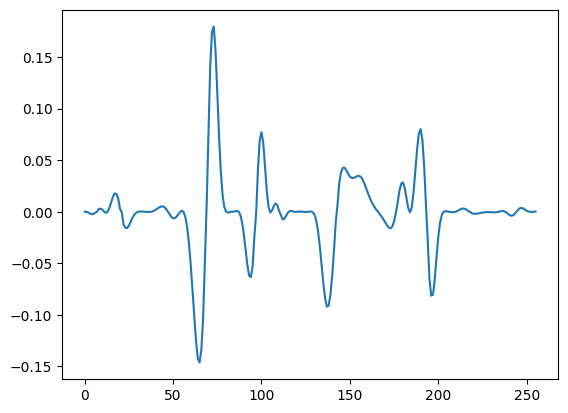

In [91]:
X = dataset[3:4,:,:19,0].unsqueeze(-1).to(device)
plt.plot((torch.roll(X, -1, dims = 2)-X)[:,:,0].detach().cpu().squeeze())

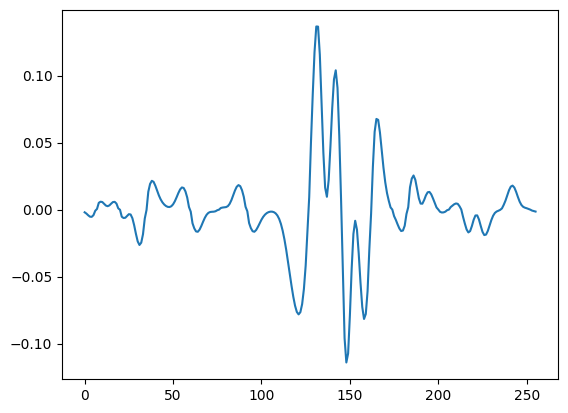

In [90]:
X = dataset[3:4,:,:19,0].unsqueeze(-1).to(device)
plt.plot((torch.roll(X, -1, dims = 2)-X)[:,:,0].detach().cpu().squeeze())

In [58]:
model = ContextFNO(16,64,5,1).to(device)

NameError: name 'ContextFNO' is not defined

In [6]:
import pickle


with open(file='trained_model_attention_new00.pickle', mode='wb') as f:
    pickle.dump(model, f)

In [7]:
torch.save(model.state_dict(), "contextfno_state_atteion_new00.pth")

In [ ]:
model = ContextFNO(8,4,8,16,3).to(device)
model.load_state_dict(torch.load("contextfno_state_22.pth", map_location=device))

In [10]:
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[1:2,:,:50,0].unsqueeze(-1).to(device)
y = []
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
model.to(device)
f0 = model.forward(X,xl)
f1 = model.forward(X,xr)
        
for i in range(50):

    x = x +(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
    xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
    
    
    f0 = model.forward(X,xl)
    f1 = model.forward(X,xr)
            

In [30]:
j = 1
x = XX[5*j:5*(j+1)]
consi = consiI[5*j:5*(j+1)]
model.train()
t1 = default_timer()
train_mse = 0
train_l2 = 0
train_l2_2 = 0


xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)

NameError: name 'model' is not defined

In [102]:
dataset[:2,:,0,0].unsqueeze(-1).to(device).shape

torch.Size([2, 256, 1])

In [103]:
dataset[:1,:,:,0].unsqueeze(-1).to(device).shape

torch.Size([1, 256, 50, 1])

In [152]:
((torch.sum(XX, dim=3).unsqueeze(2)).permute(0, 3, 1, 2).flatten(start_dim=0, end_dim=1)).shape

torch.Size([5000, 256, 1])

In [155]:
torch.sum(XX, dim=2).unsqueeze(2).shape

torch.Size([100, 256, 1, 1])

In [156]:
XX.shape

torch.Size([100, 256, 50, 1])

In [121]:
X.shape

torch.Size([1, 20, 20, 1])

In [10]:
model.eval()
dt_over_dx = 0.128

with torch.inference_mode():
    NNN = 1
    x = dataset[NNN:NNN+1, :, 0, 0].unsqueeze(-1).to(device)          # [1,Nx,1]
    X = dataset[NNN:NNN+1, :, 0:20, 0].unsqueeze(-1).to(device)        # [1,Nx,5,1]

    for _ in range(20):
        xl = torch.cat((torch.roll(x, -2, 1),
                        torch.roll(x, -1, 1),
                        x,
                        torch.roll(x,  1, 1)), dim=2)    # [1,Nx,1,4]
        xr = torch.cat((torch.roll(x, -1, 1),
                        x,
                        torch.roll(x,  1, 1),
                        torch.roll(x,  2, 1)), dim=2)   # [1,Nx,1,4]

        f0 = model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19], xl)              # [1,Nx,1,1]
        f1 = model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19], xr)              # [1,Nx,1,1]


        x  = x + dt_over_dx * (f0 - f1)

        # (선택) 컨텍스트 슬라이딩 갱신
        # X = torch.cat([X[:, :, 1:, :], x.unsqueeze(2)], dim=2)       # [1,Nx,5,1]


In [29]:
model.eval()
dt_over_dx = 0.128

with torch.inference_mode():
    NNN = 4
    x = testset[NNN:NNN+1, :, 0, 0].unsqueeze(-1).to(device)          # [1,Nx,1]
    print(x.shape)
    X = testset[NNN:NNN+1, :, 0:20, 0].unsqueeze(-1).to(device)        # [1,Nx,5,1]

    for _ in range(50):
        xl = torch.cat((torch.roll(x, -2, 1),
                        torch.roll(x, -1, 1),
                        x,
                        torch.roll(x,  1, 1)), dim=2)   # [1,Nx,1,4]

        xr = torch.cat((torch.roll(x, -1, 1),
                        x,
                        torch.roll(x,  1, 1),
                        torch.roll(x,  2, 1)), dim=2)  # [1,Nx,1,4]

        f0 = model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19], xl)              # [1,Nx,1,1]
        f1 = model.forward(100*(torch.roll(X, -1, dims = 2)-X)[:,:,0:19], xr)              # [1,Nx,1,1]

        x  = x + dt_over_dx * (f0 - f1)

        # (선택) 컨텍스트 슬라이딩 갱신
        # X = torch.cat([X[:, :, 1:, :], x.unsqueeze(2)], dim=2)       # [1,Nx,5,1]


torch.Size([1, 256, 1])


In [13]:
x = testset[:2,:,:,0].unsqueeze(-1).to(device)

y = []
xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)
f1 = model.train_forward(x,xr)
        
for i in range():

    x = x -(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
    xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)
    
    f0 = model.train_forward(X,xl)
    f1 = model.train_forward(X,xr)
            

AttributeError: 'ContextFNO' object has no attribute 'train_forward'

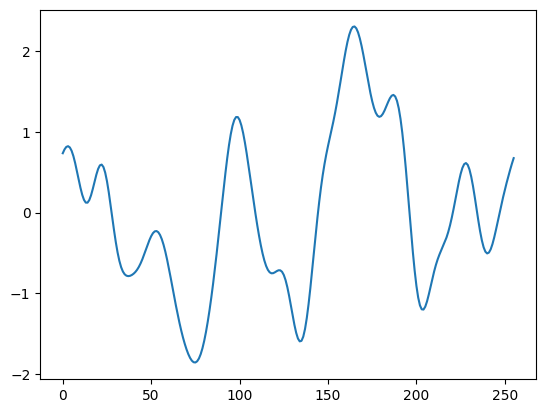

In [33]:
plt.plot(testset.detach().cpu()[0,:,0,0])

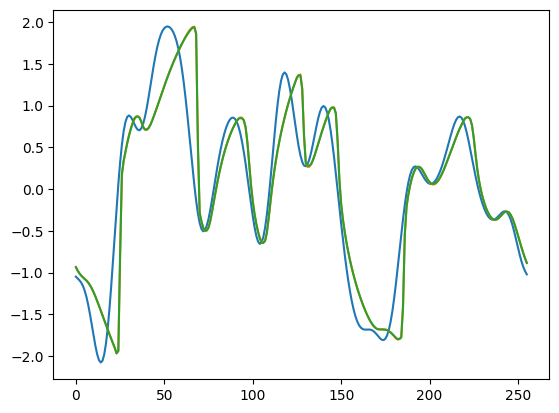

In [11]:
M = 0
plt.plot(dataset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(dataset.detach().cpu()[NNN,:,20,0])

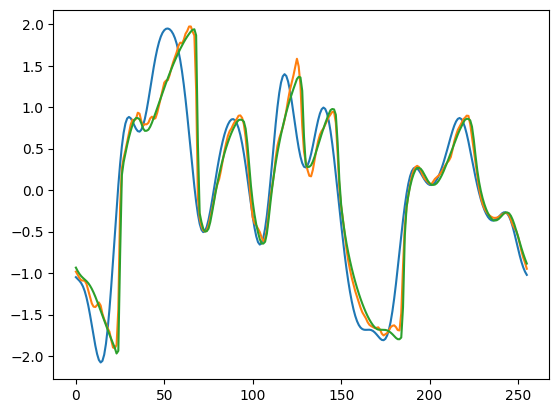

In [27]:
M = 0
plt.plot(dataset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(dataset.detach().cpu()[NNN,:,20,0])

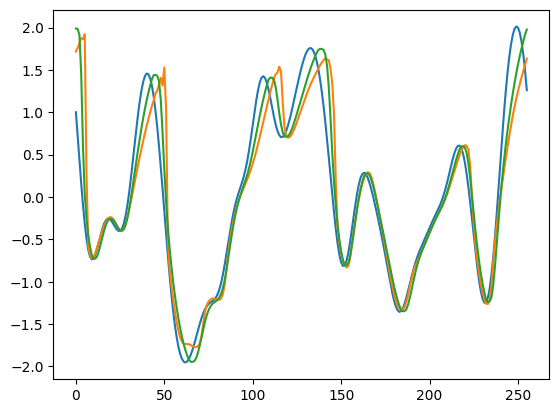

In [30]:
M = 0
plt.plot(testset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(testset.detach().cpu()[NNN,:,50,0])

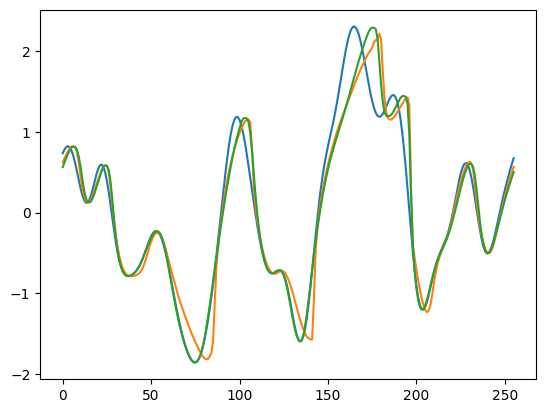

In [17]:
M = 0
plt.plot(testset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(testset.detach().cpu()[NNN,:,20,0])

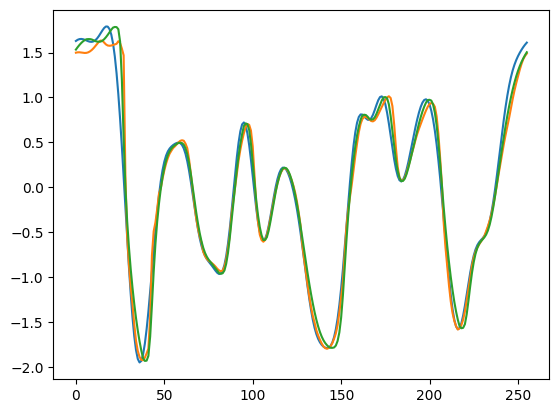

In [75]:
M = 0
plt.plot(testset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(testset.detach().cpu()[NNN,:,10,0])

## x

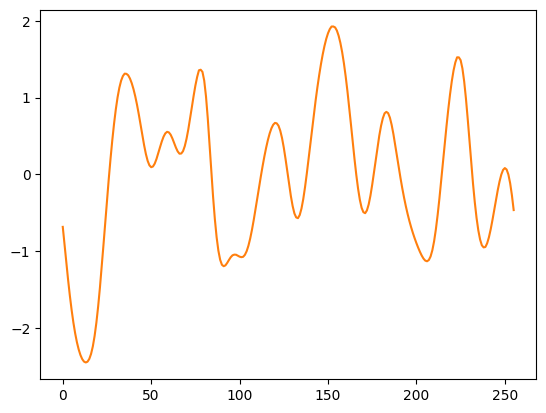

In [19]:


#plt.plot(x[0].detach().cpu()+ 0.256/5*(f0[0,:,:]-f1[0,:,:]).detach().cpu())
#plt.plot(X[0,:,0,:].detach().cpu())
plt.plot(x[0].detach().squeeze().cpu())
plt.plot(X[0,:,99,:].detach().cpu())

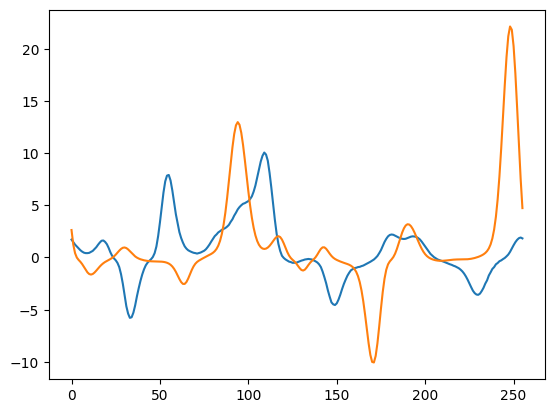

In [21]:
plt.plot(MM.detach().cpu()[0,:,0,0])
plt.plot(dataset[:,:,:,1].unsqueeze(-1).detach().cpu()[0,:,0,0])

In [ ]:
plt.plot(dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,1,0]-dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,0,0])

In [129]:
"""
All-in-one: Stable Context Attention Encoder + Positional Encoding + Pooling Options + Diagnostics

What you get in this single file
- build_nd_posenc: Fourier N-D positional encoding that matches your original signature
- LearnedPos: fallback learned positional embedding (robust)
- AttnPool: attention-based pooling to avoid mean-pooling collapse
- ContextAttentionEncoder: drop-in, configurable (posenc='auto'|'fourier'|'learned', pool='attn'|'cls'|'mean'|'meanmax')
- StableContextEncoder: minimal, rock-solid baseline to compare against
- Diagnostics: quick_probe, register_std_probes/run_probe, bisect_variance, fingerprint
- Training helper: make_optimizer with no_decay grouping for norms/bias/pos/gates

Usage sketch (see bottom for quick self-test):
    model = ContextAttentionEncoder(posenc='auto', pool='attn')
    x = torch.randn(8, 8, 8, 32)  # [B, D1, D2, ..., C]
    z = model(x)

"""

from typing import Tuple, List
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------
# Positional Encodings
# ------------------------------

def build_nd_posenc(spatial: Tuple[int, ...], device, num_freqs: int = 8, use_sincos: bool = True) -> torch.Tensor:
    """
    Fourier N-D positional encoding compatible with your original call.
    Returns: [1, N, P] where N = prod(spatial), P = (2 * num_freqs * ndim) [+ ndim if not use_sincos]
    - Coordinates are normalized to [0,1].
    - Frequencies are powers of 2: 2^k * pi.
    """
    assert len(spatial) >= 1, "Need at least 1 spatial dimension"
    grids = [torch.linspace(0.0, 1.0, s, device=device) for s in spatial]
    mesh = torch.meshgrid(*grids, indexing='ij')  # list of [d1,...,dn]
    coords = [m.reshape(-1, 1) for m in mesh]     # each [N,1]
    N = coords[0].shape[0]
    ndim = len(spatial)

    if use_sincos:
        feats = []
        for d in range(ndim):
            c = coords[d]  # [N,1]
            for k in range(num_freqs):
                freq = (2.0 ** k) * math.pi
                feats.append(torch.sin(c * freq))  # [N,1]
                feats.append(torch.cos(c * freq))  # [N,1]
        out = torch.cat(feats, dim=1)  # [N, 2*num_freqs*ndim]
    else:
        out = torch.cat(coords, dim=1)  # [N, ndim]

    return out.unsqueeze(0)  # [1, N, P]


class LearnedPos(nn.Module):
    """Learned positional embedding that adapts to N=prod(spatial)."""
    def __init__(self, d_model: int):
        super().__init__()
        self.pe: torch.nn.Parameter | None = None
        self.d = d_model

    def forward(self, spatial: Tuple[int, ...], B: int, device) -> torch.Tensor:
        N = int(torch.tensor(spatial, device=device).prod())
        if (self.pe is None) or (self.pe.shape[1] != N) or (self.pe.device != device):
            self.pe = nn.Parameter(torch.zeros(1, N, self.d, device=device))
            nn.init.trunc_normal_(self.pe, std=0.02)
        return self.pe.expand(B, -1, -1)  # [B, N, d]


# ------------------------------
# Pooling
# ------------------------------

class AttnPool(nn.Module):
    """Single learned query attends over tokens to produce a pooled vector."""
    def __init__(self, d_model: int, nhead: int = 4):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.query, std=0.02)
        self.attn = nn.MultiheadAttention(d_model, max(1, nhead), batch_first=True)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h: [B, N, d]
        B = h.size(0)
        q = self.query.expand(B, 1, -1)  # [B,1,d]
        out, _ = self.attn(q, h, h, need_weights=False)  # [B,1,d]
        return out[:, 0, :]  # [B,d]


# ------------------------------
# Encoders
# ------------------------------

class ContextAttentionEncoder(nn.Module):
    """
    Drop-in, configurable encoder.
    - posenc: 'auto'|'fourier'|'learned'
        * 'auto': try Fourier; if it collapses, you can switch to 'learned' without other changes
    - pool: 'attn'|'cls'|'mean'|'meanmax'
        * 'attn' (default) avoids mean-pooling flatness
    - use_cls: still supported; for pool='cls' it uses the prepended token
    """
    def __init__(self, d_model=256, nhead=8, num_layers=4, dim_ff=1024,
                 out_dim=128, num_freqs=8, use_cls=True, dropout=0.1,
                 posenc: str = 'auto', pool: str = 'attn', pos_gate_init: float = 1.0):
        super().__init__()
        assert posenc in {'auto', 'fourier', 'learned'}
        assert pool in {'attn', 'cls', 'mean', 'meanmax'}
        self.use_cls = use_cls
        self.num_freqs = num_freqs
        self.posenc_kind = posenc
        self.pool_kind = pool

        # Content projection (Lazy to infer input channels at runtime)
        self.in_proj = nn.LazyLinear(d_model, bias=True)

        # Positional components
        if posenc in {'auto', 'fourier'}:
            self.pos_proj = nn.LazyLinear(d_model, bias=False)  # pos -> d_model
            # gated scale; make it strictly positive via softplus during forward
            self.pos_scale = nn.Parameter(torch.tensor(float(pos_gate_init)))  # raw; softplus in forward
        if posenc in {'auto', 'learned'}:
            self.learned_pos = LearnedPos(d_model)

        # Encoder (no extra pre-LN; layers are norm_first=True already)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model))

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Pooling
        if pool == 'attn':
            self.pool = AttnPool(d_model, nhead=max(1, nhead // 2))
            head_in = d_model
        elif pool == 'cls':
            self.pool = None
            head_in = d_model
        elif pool == 'mean':
            self.pool = None
            head_in = d_model
        elif pool == 'meanmax':
            self.pool = None
            head_in = 2 * d_model
        else:
            raise ValueError("Unknown pool kind")

        # Head
        self.head = nn.Sequential(
            nn.Linear(head_in, d_model), nn.GELU(),
            nn.Linear(d_model, out_dim)
        )
        # Init head
        nn.init.xavier_uniform_(self.head[0].weight); nn.init.zeros_(self.head[0].bias)
        nn.init.xavier_uniform_(self.head[2].weight); nn.init.zeros_(self.head[2].bias)

    @staticmethod
    def _softplus_pos(x: torch.Tensor) -> torch.Tensor:
        return F.softplus(x) + 1e-4

    def _make_pos(self, spatial: Tuple[int, ...], B: int, device) -> torch.Tensor:
        """Return position embedding aligned to d_model, shape [B, N, d_model]."""
        if self.posenc_kind in {'auto', 'fourier'}:
            pos_raw = build_nd_posenc(spatial, device, num_freqs=self.num_freqs, use_sincos=True)  # [1,N,P]
            pos = self.pos_proj(pos_raw.expand(B, -1, -1))  # [B,N,d]
            pos = self._softplus_pos(self.pos_scale) * pos
        else:
            pos = self.learned_pos(spatial, B, device)
        return pos

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, D1, D2, ..., C]
        returns: [B, out_dim]
        """
        B, *spatial, C = x.shape
        device = x.device
        xtok = x.reshape(B, -1, C)                 # [B, N, C]

        h = self.in_proj(xtok)                     # [B, N, d]
        pos = self._make_pos(tuple(spatial), B, device)  # [B, N, d]
        h = h + pos                                 # inject position

        if self.use_cls:
            cls = self.cls_token.expand(B, 1, -1)  # [B,1,d]
            h = torch.cat([cls, h], dim=1)         # [B,1+N,d]

        h = self.encoder(h)                         # [B,1+N,d] or [B,N,d]

        if self.pool_kind == 'attn':
            if self.use_cls:
                tokens = h[:, 1:, :]  # exclude CLS to avoid trivial shortcut
            else:
                tokens = h
            pooled = self.pool(tokens)              # [B,d]
        elif self.pool_kind == 'cls' and self.use_cls:
            pooled = h[:, 0, :]
        elif self.pool_kind == 'mean':
            if self.use_cls:
                pooled = h[:, 1:, :].mean(dim=1)
            else:
                pooled = h.mean(dim=1)
        elif self.pool_kind == 'meanmax':
            if self.use_cls:
                toks = h[:, 1:, :]
            else:
                toks = h
            pooled = torch.cat([toks.mean(dim=1), toks.amax(dim=1)], dim=-1)
        else:
            raise ValueError("Pooling configuration invalid for current settings.")

        z = self.head(pooled)
        return z


def downsample_along_Nd(x, Nd_max=512):
    """
    x: [B, N_d, N_t, C] (채널 마지막)
    반환: [B, N_d', N_t, C]  where N_d' = min(N_d, Nd_max)
    분산 보존을 위해 sqrt(N_d / N_d')로 게인 보정
    """
    B, Nd, Nt, C = x.shape
    if Nd_max is None or Nd <= Nd_max:
        return x
    flat = x.reshape(B, Nd, Nt*C).transpose(1, 2)            # [B, Nt*C, Nd]
    ds   = F.adaptive_avg_pool1d(flat, Nd_max).transpose(1, 2)  # [B, Nd', Nt*C]
    gain = math.sqrt(Nd / float(Nd_max))
    ds   = (ds * gain).reshape(B, Nd_max, Nt, C)
    return ds



class AttnPool(nn.Module):
    def __init__(self, d_model, nhead=4):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(1,1,d_model))
        nn.init.trunc_normal_(self.query, std=0.02)
        self.attn  = nn.MultiheadAttention(d_model, max(1, nhead), batch_first=True)
        # ★ log-scale(배율=exp(s)): N 커져도 예리함 유지
        self.logit_logscale = nn.Parameter(torch.tensor(0.0))  # init=0 => scale=1.0

    def forward(self, h):  # h: [B, N, d]
        B = h.size(0)
        q = self.query.expand(B,1,-1) * self.logit_logscale.exp()   # ← 로짓 스케일 업
        out, _ = self.attn(q, h, h, need_weights=False)
        return out[:,0,:]


def set_attn_scale_for_length(module, N, base=1.0):
    # 원하는 N에서 scale≈base*log(N)
    with torch.no_grad():
        module.logit_logscale.copy_(torch.tensor(math.log(base * math.log(N+1))))

        
class StableContextEncoder(nn.Module):
    """A minimal, highly stable variant for sanity checking."""
    def __init__(self, d_model=256, nhead=4, num_layers=2, dim_ff=1024,
                 out_dim=128, dropout=0.1):
        super().__init__()
        self.in_proj = nn.LazyLinear(d_model)
        self.pos     = LearnedPos(d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers, norm=nn.LayerNorm(d_model))
        self.pool    = AttnPool(d_model, nhead=max(1, nhead // 2))
        self.head    = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Linear(d_model, out_dim))
        for i in [0, 2]:
            nn.init.xavier_uniform_(self.head[i].weight); nn.init.zeros_(self.head[i].bias)
        self.cls_token = None  # not used here

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, *spatial, C = x.shape
        dev = x.device
        xtok = x.reshape(B, -1, C)
        h = self.in_proj(xtok) + self.pos(tuple(spatial), B, dev)
        h = self.encoder(h)
        pooled = self.pool(h)
        return self.head(pooled)


# ------------------------------
# Diagnostics & Probes
# ------------------------------

def quick_probe(model: nn.Module, x: torch.Tensor):
    """Print basic std statistics through the forward path."""
    model.eval()
    with torch.no_grad():
        B, *spatial, C = x.shape
        xtok = x.reshape(B, -1, C)
        print(f"[x] global std: {xtok.std().item():.6f}")
        # pos raw
        if hasattr(model, '_make_pos'):
            pos = model._make_pos(tuple(spatial), B, x.device)
            print(f"[pos] std: {pos.std().item():.6f}")
        hx = model.in_proj(xtok)
        print(f"[in_proj(x)] std: {hx.std().item():.6f}")
        if hasattr(model, '_make_pos'):
            hp = hx + model._make_pos(tuple(spatial), B, x.device)
            print(f"[in+pos] std: {hp.std().item():.6f}")
        z = model(x)
        print(f"[model(z)] std: {z.std().item():.6f}")


def register_std_probes(model: nn.Module):
    """Attach forward hooks to capture std at major modules; returns handles to remove later."""
    probes = []
    stats_key = '_stats'
    def hook(name):
        def fn(mod, inp, out):
            t = out if isinstance(out, torch.Tensor) else out[0]
            model.__dict__.setdefault(stats_key, {})[name] = float(t.detach().std())
        return fn

    if hasattr(model, 'in_proj'): probes.append(model.in_proj.register_forward_hook(hook('in_proj')))
    if hasattr(model, 'pos_proj'): probes.append(model.pos_proj.register_forward_hook(hook('pos_proj')))
    if hasattr(model, 'pool') and isinstance(model.pool, nn.Module):
        probes.append(model.pool.register_forward_hook(hook('pool_in')))
    # Encoder layers
    enc = getattr(model, 'encoder', None)
    if enc is not None and hasattr(enc, 'layers'):
        for i, layer in enumerate(enc.layers):
            probes.append(layer.register_forward_hook(hook(f'enc[{i}]')))
    # Head
    probes.append(model.head.register_forward_hook(hook('head_in')))
    return probes


def run_probe(model: nn.Module, x: torch.Tensor):
    """Run a forward pass with hooks and estimate input sensitivity (grad std)."""
    model.eval()
    probes = register_std_probes(model)
    try:
        with torch.no_grad():
            z = model(x)
        stats = getattr(model, '_stats', {})
        stats['output_std'] = float(z.std())
        # sensitivity: d(sum z)/d x
        x_req = x.detach().clone().requires_grad_(True)
        z2 = model(x_req)
        z2.sum().backward()
        grad_std = float(x_req.grad.std()) if x_req.grad is not None else 0.0
        stats['d(output)/d(input)_std'] = grad_std
        return z, stats
    finally:
        for h in probes:
            h.remove()


def bisect_variance(model: nn.Module, x: torch.Tensor):
    """Report std after each logical step to localize collapse."""
    model.eval()
    with torch.no_grad():
        B, *spatial, C = x.shape
        xtok = x.reshape(B, -1, C)
        stats = {}
        h = model.in_proj(xtok); stats['in_proj(x)'] = h.std().item()
        if hasattr(model, '_make_pos'):
            h = h + model._make_pos(tuple(spatial), B, x.device)
            stats['+pos'] = h.std().item()
        if getattr(model, 'use_cls', False):
            h = torch.cat([model.cls_token.expand(B, 1, -1), h], dim=1)
            stats['+cls'] = h.std().item()
        cur = h
        enc = getattr(model, 'encoder', None)
        if enc is not None and hasattr(enc, 'layers'):
            for i, layer in enumerate(enc.layers):
                cur = layer(cur)
                stats[f'enc[{i}]'] = cur.std().item()
        # pooling
        if getattr(model, 'pool_kind', 'attn') == 'attn':
            toks = cur[:, 1:, :] if getattr(model, 'use_cls', False) else cur
            pooled = model.pool(toks)
        elif model.pool_kind == 'cls' and getattr(model, 'use_cls', False):
            pooled = cur[:, 0, :]
        elif model.pool_kind == 'mean':
            pooled = (cur[:, 1:, :].mean(dim=1) if getattr(model, 'use_cls', False) else cur.mean(dim=1))
        else:  # meanmax
            toks = cur[:, 1:, :] if getattr(model, 'use_cls', False) else cur
            pooled = torch.cat([toks.mean(dim=1), toks.amax(dim=1)], dim=-1)
        stats['pool'] = pooled.std().item()
        z = model.head(pooled); stats['head'] = z.std().item()
        return stats


def fingerprint(x: torch.Tensor) -> torch.Tensor:
    """Quick batch similarity fingerprint. If std≈0, your batch is effectively identical."""
    return torch.round(x.float().mean(dim=tuple(range(1, x.ndim))), decimals=4)


# ------------------------------
# Training helper (optimizer)
# ------------------------------

def make_optimizer(model: nn.Module, lr: float = 3e-4, weight_decay: float = 0.05) -> torch.optim.Optimizer:
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        name = n.lower()
        if name.endswith('bias') or ('norm' in name) or ('ln' in name) or ('pos' in name) or ('query' in name) or ('scale' in name):
            no_decay.append(p)
        else:
            decay.append(p)
    return torch.optim.AdamW(
        [
            {'params': decay, 'weight_decay': weight_decay},
            {'params': no_decay, 'weight_decay': 0.0},
        ], lr=lr, betas=(0.9, 0.95)
    )


# ------------------------------
# Quick self-test (optional)
# ------------------------------
if __name__ == '__main__':
    torch.manual_seed(0)
    B, D1, D2, C = 6, 8, 8, 32
    x = torch.randn(B, D1, D2, C)

    print("\n=== ContextAttentionEncoder (auto/attn) ===")
    model = ContextAttentionEncoder(out_dim=128, posenc='auto', pool='attn')
    z, stats = run_probe(model, x)
    print("stats:", stats)

    print("\n=== StableContextEncoder (baseline) ===")
    stable = StableContextEncoder(out_dim=128)
    z2, stats2 = run_probe(stable, x)
    print("stats:", stats2)

    print("\n=== Bisect Variance (ContextAttentionEncoder) ===")
    bstats = bisect_variance(model, x)
    for k, v in bstats.items():
        print(f"{k:>12s} : {v:.6f}")

    print("\n=== Batch fingerprint ===")
    fp = fingerprint(x)
    print("fp std:", fp.std().item())

    print("\n=== make_optimizer() demo ===")
    opt = make_optimizer(model)
    print(opt)



=== ContextAttentionEncoder (auto/attn) ===
stats: {'in_proj': 0.5884045362472534, 'pos_proj': 0.4038088619709015, 'enc[0]': 0.8131191730499268, 'enc[1]': 0.896416425704956, 'enc[2]': 1.0212997198104858, 'enc[3]': 1.1798683404922485, 'pool_in': 0.17500700056552887, 'head_in': 0.09962546080350876, 'output_std': 0.09962546080350876, 'd(output)/d(input)_std': 0.010470357723534107}

=== StableContextEncoder (baseline) ===
stats: {'in_proj': 0.5837916731834412, 'enc[0]': 0.6229066848754883, 'enc[1]': 0.7278105020523071, 'pool_in': 0.16827793419361115, 'head_in': 0.11497224122285843, 'output_std': 0.11497224122285843, 'd(output)/d(input)_std': 0.01071296725422144}

=== Bisect Variance (ContextAttentionEncoder) ===
  in_proj(x) : 0.588405
        +pos : 0.789290
        +cls : 0.783199
      enc[0] : 0.813119
      enc[1] : 0.896416
      enc[2] : 1.021300
      enc[3] : 1.179868
        pool : 0.209301
        head : 0.120801

=== Batch fingerprint ===
fp std: 0.020997999235987663

=== make